<a href="https://colab.research.google.com/github/amann45/NeuralMachineTranslation-NMT/blob/main/COMPARATIVE_ANALYSIS_OF_NMTarchitectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

import re
import gc
import csv
import math
import json
import time
import random
import zipfile
import hashlib
import urllib.request
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

In [3]:
SEED = 10
LANGUAGE_PAIR = "kor"

# DATASET:
DATASET_URLS = {
    "kor": "https://www.manythings.org/anki/kor-eng.zip"
}

DATASET_NAMES = {
    "kor": "English-Korean"
}

DATA_DIR = Path("nmt_comparative_analysis/data/")
PLOT_DIR = Path("nmt_comparative_analysis/plots/")
RESULT_DIR = Path("nmt_comparative_analysis/results/")
CHECKPOINT_DIR = Path("nmt_comparative_analysis/checkpoints/")
OUTPUT_DIR = Path("nmt_comparative_analysis/")

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# HYPERPARAMETERS:
EMBEDDING_DIM = 256
HIDDEN_DIM = 256
MAX_SEQ_LEN = 30
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_PAIRS = 50000  # Set to None for all pairs.

# TRAINING:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
OPTIMIZER_NAME = "Adam"
LOSS_NAME = "CrossEntropyLoss"
CLIP_VALUE = 1.0
NUM_EPOCHS = 10
TEACHER_FORCING_START = 1.0
TEACHER_FORCING_END = 0.5

# EVALUATION:
MAX_GENERATION_LEN = 30

# DATA SPLIT:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# MISCELLANEOUS:
NUM_WORKERS = 2  # Number of DataLoader workers.
STRICT_DETERMINISM = True # Try to use deterministic CUDA algorithms where available.

In [4]:
def seed_everything(seed=10):
    """
    Enforce reproducibility across Python, NumPy and PyTorch.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    # cuDNN deterministic behavior.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if STRICT_DETERMINISM:
        try:
            torch.use_deterministic_algorithms(True)
        except Exception as exc:
            print(
                "Warning: torch.use_deterministic_algorithms(True) "
                f"could not be fully enabled: {exc}"
            )


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("NMT COMPARATIVE ANALYSIS")
print("=" * 70)
print(f"Seed:       {SEED}")
print(f"Device:     {DEVICE}")
print(f"Language:   {DATASET_NAMES[LANGUAGE_PAIR]}")
print(f"Max pairs:  {MAX_PAIRS if MAX_PAIRS is not None else 'ALL'}")
print("=" * 70)


NMT COMPARATIVE ANALYSIS
Seed:       10
Device:     cpu
Language:   English-Korean
Max pairs:  50000


In [5]:
def download_dataset(language_pair):
    url = DATASET_URLS[language_pair]

    zip_path = DATA_DIR / f"{language_pair}-eng.zip"
    extract_dir = DATA_DIR / f"{language_pair}-eng"

    if not zip_path.exists():
        print(f"\nDownloading dataset:")
        print(url)

        # Add a more detailed User-Agent header to avoid HTTP Error 406 (Not Acceptable)
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req) as response:
            with open(zip_path, 'wb') as out_file:
                out_file.write(response.read())

        print(f"Downloaded: {zip_path}")

    if not extract_dir.exists():
        extract_dir.mkdir(parents=True, exist_ok=True)

        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

    # Locate .txt file robustly.
    txt_files = list(extract_dir.rglob("*.txt"))

    if not txt_files:
        raise FileNotFoundError(
            f"No translation .txt file found in {extract_dir}"
        )

    # Prefer the expected filename.
    expected_name = f"{language_pair}-eng.txt"

    for file_path in txt_files:
        if file_path.name.lower() == expected_name:
            return file_path

    return txt_files[0]


DATASET_FILE = download_dataset(LANGUAGE_PAIR)

print(f"\nDataset file: {DATASET_FILE}")


https://www.manythings.org/anki/kor-eng.zip
Downloaded: nmt_comparative_analysis/data/kor-eng.zip
Extracting dataset...

Dataset file: nmt_comparative_analysis/data/kor-eng/kor.txt


In [6]:
def normalize_text(text):
    """
    Conservative text normalization.

    We preserve accented characters because French/Spanish
    translation quality depends on them.
    """
    text = text.strip().lower()

    # Normalize Unicode apostrophes and quotes.
    replacements = {
        "\u2018": "'",
        "\u2019": "'",
        "\u201c": '"',
        "\u201d": '"',
        "\u00a0": " ",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # Collapse whitespace.
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [7]:
def load_parallel_corpus(file_path):
    """
    ManyThings format:

        EnglishTargetAttribution

    We only use the first two columns.
    """

    pairs = []

    with open(
        file_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split("\t")

            if len(parts) < 2:
                continue

            english = normalize_text(parts[0])
            target = normalize_text(parts[1])

            if not english or not target:
                continue

            pairs.append(
                (english, target)
            )

    return pairs


all_pairs = load_parallel_corpus(DATASET_FILE)

print(f"Raw usable sentence pairs: {len(all_pairs):,}")

Raw usable sentence pairs: 6,394


In [8]:
def tokenize(text):
    """
    Simple whitespace tokenizer.

    This intentionally avoids an external tokenizer so the
    experimental setup remains deterministic and reproducible.
    """
    return text.split()


def filter_pairs(pairs, max_len):
    filtered = []

    for src, trg in pairs:

        src_tokens = tokenize(src)
        trg_tokens = tokenize(trg)

        # +2 for SOS/EOS.
        if len(src_tokens) + 2 > max_len:
            continue

        if len(trg_tokens) + 2 > max_len:
            continue

        filtered.append(
            (src, trg)
        )

    return filtered


all_pairs = filter_pairs(
    all_pairs,
    MAX_SEQ_LEN
)

print(
    f"After sequence-length filtering: "
    f"{len(all_pairs):,}"
)


After sequence-length filtering: 6,392


In [9]:
def deterministic_sample(pairs, max_pairs, seed):
    """
    RandomState(seed) is used explicitly to satisfy the requested
    random_state=4 experimental protocol.
    """

    if max_pairs is None or max_pairs >= len(pairs):
        return pairs

    rng = np.random.RandomState(seed)

    indices = rng.choice(
        len(pairs),
        size=max_pairs,
        replace=False
    )

    indices = np.sort(indices)

    return [
        pairs[i]
        for i in indices
    ]


pairs = deterministic_sample(
    all_pairs,
    MAX_PAIRS,
    SEED
)

print(
    f"Pairs selected for experiment: "
    f"{len(pairs):,}"
)


Pairs selected for experiment: 6,392


In [10]:
def split_dataset(pairs, seed=4):
    """
    Explicit random_state=4 style split.

    80% train
    10% validation
    10% test
    """

    rng = np.random.RandomState(seed)

    indices = np.arange(len(pairs))
    rng.shuffle(indices)

    n = len(indices)

    train_end = int(
        TRAIN_RATIO * n
    )

    val_end = train_end + int(
        VAL_RATIO * n
    )

    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    train_pairs = [pairs[i] for i in train_indices]
    val_pairs = [pairs[i] for i in val_indices]
    test_pairs = [pairs[i] for i in test_indices]

    return (
        train_pairs,
        val_pairs,
        test_pairs
    )


train_pairs, val_pairs, test_pairs = split_dataset(
    pairs,
    SEED
)

print("\nDataset split:")
print(f"Train: {len(train_pairs):,}")
print(f"Val:   {len(val_pairs):,}")
print(f"Test:  {len(test_pairs):,}")



Dataset split:
Train: 5,113
Val:   639
Test:  640


In [11]:
PAD_TOKEN = ""
SOS_TOKEN = ""
EOS_TOKEN = ""
UNK_TOKEN = ""

SPECIAL_TOKENS = [
    PAD_TOKEN,
    SOS_TOKEN,
    EOS_TOKEN,
    UNK_TOKEN,
]


class Vocabulary:

    def __init__(
        self,
        max_size=None,
        min_freq=1
    ):
        self.max_size = max_size
        self.min_freq = min_freq

        self.token_to_idx = {}
        self.idx_to_token = {}

        for token in SPECIAL_TOKENS:
            self._add_token(token)

    def _add_token(self, token):
        if token not in self.token_to_idx:

            idx = len(self.token_to_idx)

            self.token_to_idx[token] = idx
            self.idx_to_token[idx] = token

    def build(self, sentences):

        counter = Counter()

        for sentence in sentences:

            for token in tokenize(sentence):
                counter[token] += 1

        tokens = [
            token
            for token, count in counter.items()
            if count >= self.min_freq
        ]

        # Most frequent tokens first.
        tokens.sort(
            key=lambda token: (
                -counter[token],
                token
            )
        )

        if self.max_size is not None:

            available_slots = (
                self.max_size -
                len(SPECIAL_TOKENS)
            )

            tokens = tokens[:max(0, available_slots)]

        for token in tokens:
            self._add_token(token)

    def encode(
        self,
        sentence,
        max_len
    ):

        tokens = tokenize(sentence)

        ids = [
            self.token_to_idx[SOS_TOKEN]
        ]

        unk_id = self.token_to_idx[UNK_TOKEN]

        for token in tokens:

            ids.append(
                self.token_to_idx.get(
                    token,
                    unk_id
                )
            )

        ids.append(
            self.token_to_idx[EOS_TOKEN]
        )

        # Truncate while preserving EOS.
        ids = ids[:max_len]

        if ids[-1] != self.token_to_idx[EOS_TOKEN]:
            ids[-1] = self.token_to_idx[EOS_TOKEN]

        # Pad.
        ids += [
            self.token_to_idx[PAD_TOKEN]
        ] * (max_len - len(ids))

        return ids

    def decode(
        self,
        ids,
        remove_special=True
    ):

        tokens = []

        for idx in ids:

            token = self.idx_to_token.get(
                int(idx),
                UNK_TOKEN
            )

            if token == EOS_TOKEN:
                break

            if remove_special and token in SPECIAL_TOKENS:
                continue

            tokens.append(token)

        return tokens

    def __len__(self):
        return len(self.token_to_idx)


src_vocab = Vocabulary(
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

trg_vocab = Vocabulary(
    max_size=MAX_VOCAB_SIZE,
    min_freq=MIN_FREQ
)

src_vocab.build(
    src for src, _ in train_pairs
)

trg_vocab.build(
    trg for _, trg in train_pairs
)

print("\nVocabulary:")
print(f"Source vocabulary: {len(src_vocab):,}")
print(f"Target vocabulary: {len(trg_vocab):,}")


SRC_PAD_IDX = src_vocab.token_to_idx[PAD_TOKEN]
SRC_SOS_IDX = src_vocab.token_to_idx[SOS_TOKEN]
SRC_EOS_IDX = src_vocab.token_to_idx[EOS_TOKEN]

TRG_PAD_IDX = trg_vocab.token_to_idx[PAD_TOKEN]
TRG_SOS_IDX = trg_vocab.token_to_idx[SOS_TOKEN]
TRG_EOS_IDX = trg_vocab.token_to_idx[EOS_TOKEN]


Vocabulary:
Source vocabulary: 2,044
Target vocabulary: 2,363


In [12]:
# PYTORCH DATASET
class TranslationDataset(Dataset):

    def __init__(
        self,
        pairs,
        src_vocab,
        trg_vocab,
        max_len
    ):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        src_text, trg_text = self.pairs[idx]

        src_ids = self.src_vocab.encode(
            src_text,
            self.max_len
        )

        trg_ids = self.trg_vocab.encode(
            trg_text,
            self.max_len
        )

        return {
            "src": torch.tensor(
                src_ids,
                dtype=torch.long
            ),
            "trg": torch.tensor(
                trg_ids,
                dtype=torch.long
            ),
            "src_text": src_text,
            "trg_text": trg_text,
        }


train_dataset = TranslationDataset(
    train_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)

val_dataset = TranslationDataset(
    val_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)

test_dataset = TranslationDataset(
    test_pairs,
    src_vocab,
    trg_vocab,
    MAX_SEQ_LEN
)


def create_dataloader(
    dataset,
    shuffle,
    seed
):

    generator = torch.Generator()

    generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
        drop_last=False,
    )


train_loader = create_dataloader(
    train_dataset,
    shuffle=True,
    seed=SEED
)

val_loader = create_dataloader(
    val_dataset,
    shuffle=False,
    seed=SEED
)

test_loader = create_dataloader(
    test_dataset,
    shuffle=False,
    seed=SEED
)

In [13]:
# MODEL COMPONENTS

class VanillaRNNEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=SRC_PAD_IDX
        )

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.embedding(src)

        outputs, hidden = self.rnn(
            embedded
        )

        return outputs, hidden


class VanillaRNNDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        output, hidden = self.rnn(
            embedded,
            hidden
        )

        prediction = self.fc_out(
            output.squeeze(1)
        )

        return prediction, hidden


class GRUEncoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=SRC_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

    def forward(self, src):

        embedded = self.embedding(src)

        outputs, hidden = self.gru(
            embedded
        )

        return outputs, hidden


class GRUDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        output, hidden = self.gru(
            embedded,
            hidden
        )

        prediction = self.fc_out(
            output.squeeze(1)
        )

        return prediction, hidden

In [14]:
# BAHDAUNAU ADDITIVE ATTENTION
class BahdanauAttention(nn.Module):

    """
    Additive attention:

        e_ti =
            v_a^T tanh(
                W_h h_i + W_s s_t
            )

        alpha_ti =
            softmax(e_ti)

        c_t =
            sum_i alpha_ti h_i

    where:
        h_i = encoder hidden state
        s_t = decoder hidden state
    """

    def __init__(
        self,
        hidden_dim
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.decoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

        self.energy_projection = nn.Linear(
            hidden_dim,
            1,
            bias=False
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        mask
    ):

        # decoder_hidden:
        # [batch, hidden]
        #
        # encoder_outputs:
        # [batch, src_len, hidden]

        decoder_features = self.decoder_projection(
            decoder_hidden
        ).unsqueeze(1)

        encoder_features = self.encoder_projection(
            encoder_outputs
        )

        energy = torch.tanh(
            encoder_features +
            decoder_features
        )

        energy = self.energy_projection(
            energy
        ).squeeze(-1)

        energy = energy.masked_fill(
            ~mask,
            -1e9
        )

        attention = torch.softmax(
            energy,
            dim=1
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention


class AttentionDecoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        attention
    ):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=TRG_PAD_IDX
        )

        self.gru = nn.GRU(
            embedding_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            embedding_dim +
            hidden_dim +
            hidden_dim,
            output_dim
        )

    def forward(
        self,
        input_token,
        hidden,
        encoder_outputs,
        src_mask
    ):

        input_token = input_token.unsqueeze(1)

        embedded = self.embedding(
            input_token
        )

        decoder_hidden = hidden[-1]

        context, attention = self.attention(
            decoder_hidden,
            encoder_outputs,
            src_mask
        )

        gru_input = torch.cat(
            [
                embedded,
                context.unsqueeze(1)
            ],
            dim=2
        )

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        output = output.squeeze(1)

        prediction = self.fc_out(
            torch.cat(
                [
                    output,
                    context,
                    embedded.squeeze(1)
                ],
                dim=1
            )
        )

        return prediction, hidden, attention

In [15]:
# LUONG MULTIPLICATIVE ATTENTION

class LuongAttention(nn.Module):

    """
    General Luong multiplicative attention:

        score(s_t, h_i) =
            s_t^T W_a h_i

        alpha_ti =
            softmax(score(s_t, h_i))

        c_t =
            sum_i alpha_ti h_i
    """

    def __init__(
        self,
        hidden_dim
    ):
        super().__init__()

        self.encoder_projection = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        mask
    ):

        projected_encoder = self.encoder_projection(
            encoder_outputs
        )

        decoder_hidden = decoder_hidden.unsqueeze(2)

        scores = torch.bmm(
            projected_encoder,
            decoder_hidden
        ).squeeze(2)

        scores = scores.masked_fill(
            ~mask,
            -1e9
        )

        attention = torch.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context, attention

In [16]:
# SEQ2SEQ

class VanillaRNNSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.encoder = VanillaRNNEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        self.decoder = VanillaRNNDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        encoder_outputs, hidden = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden = self.decoder(
                input_token,
                hidden
            )

            outputs[:, t] = output

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, None


class GRUSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim
    ):
        super().__init__()

        self.encoder = GRUEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        self.decoder = GRUDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        _, hidden = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden = self.decoder(
                input_token,
                hidden
            )

            outputs[:, t] = output

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, None


class AttentionSeq2Seq(nn.Module):

    def __init__(
        self,
        src_dim,
        trg_dim,
        embedding_dim,
        hidden_dim,
        attention_type
    ):
        super().__init__()

        self.encoder = GRUEncoder(
            src_dim,
            embedding_dim,
            hidden_dim
        )

        if attention_type == "bahdanau":

            self.attention = BahdanauAttention(
                hidden_dim
            )

        elif attention_type == "luong":

            self.attention = LuongAttention(
                hidden_dim
            )

        else:
            raise ValueError(
                f"Unknown attention type: {attention_type}"
            )

        self.decoder = AttentionDecoder(
            trg_dim,
            embedding_dim,
            hidden_dim,
            self.attention
        )

    def forward(
        self,
        src,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            trg_vocab_size,
            device=src.device
        )

        attentions = torch.zeros(
            batch_size,
            trg_len,
            src.size(1),
            device=src.device
        )

        encoder_outputs, hidden = self.encoder(
            src
        )

        src_mask = (
            src != SRC_PAD_IDX
        )

        input_token = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, attention = (
                self.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )
            )

            outputs[:, t] = output

            attentions[:, t] = attention

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(
                dim=1
            )

            input_token = (
                trg[:, t]
                if teacher_force
                else top1
            )

        return outputs, attentions

In [17]:
# MODEL

MODEL_NAMES = [
    "Vanilla RNN",
    "GRU Seq2Seq",
    "Bahdanau Attention",
    "Luong Attention",
]


def build_model(model_name):

    if model_name == "Vanilla RNN":

        model = VanillaRNNSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM
        )

    elif model_name == "GRU Seq2Seq":

        model = GRUSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM
        )

    elif model_name == "Bahdanau Attention":

        model = AttentionSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM,
            "bahdanau"
        )

    elif model_name == "Luong Attention":

        model = AttentionSeq2Seq(
            len(src_vocab),
            len(trg_vocab),
            EMBEDDING_DIM,
            HIDDEN_DIM,
            "luong"
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model.to(DEVICE)

In [18]:
# PARAMETER COUNT
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

def teacher_forcing_ratio(epoch, total_epochs):

    if total_epochs <= 1:
        return TEACHER_FORCING_END

    progress = (
        epoch - 1
    ) / (
        total_epochs - 1
    )

    ratio = (
        TEACHER_FORCING_START +
        progress *
        (
            TEACHER_FORCING_END -
            TEACHER_FORCING_START
        )
    )

    return ratio

In [19]:
# LOSS

criterion = nn.CrossEntropyLoss(
    ignore_index=TRG_PAD_IDX
)


def calculate_loss(
    outputs,
    targets
):

    output_dim = outputs.size(-1)

    outputs = outputs[:, 1:].reshape(
        -1,
        output_dim
    )

    targets = targets[:, 1:].reshape(
        -1
    )

    return criterion(
        outputs,
        targets
    )

In [20]:
# TRAINING

def train_one_epoch(
    model,
    loader,
    optimizer,
    teacher_forcing_ratio
):

    model.train()

    epoch_loss = 0.0

    for batch in loader:

        src = batch["src"].to(
            DEVICE,
            non_blocking=True
        )

        trg = batch["trg"].to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs, _ = model(
            src,
            trg,
            teacher_forcing_ratio
        )

        loss = calculate_loss(
            outputs,
            trg
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CLIP_VALUE
        )

        optimizer.step()

        epoch_loss += (
            loss.item()
            * src.size(0)
        )

    return epoch_loss / len(loader.dataset)


In [21]:
# VALIDATION

@torch.no_grad()
def evaluate_loss(
    model,
    loader
):

    model.eval()

    epoch_loss = 0.0

    for batch in loader:

        src = batch["src"].to(
            DEVICE,
            non_blocking=True
        )

        trg = batch["trg"].to(
            DEVICE,
            non_blocking=True
        )

        outputs, _ = model(
            src,
            trg,
            teacher_forcing_ratio=1.0
        )

        loss = calculate_loss(
            outputs,
            trg
        )

        epoch_loss += (
            loss.item()
            * src.size(0)
        )

    return epoch_loss / len(loader.dataset)


In [22]:
# TRAIN MODEL

def train_model(
    model_name
):

    print("\n")
    print("=" * 70)
    print(f"TRAINING: {model_name}")
    print("=" * 70)

    # Reset seed before each model so initialization is reproducible.
    seed_everything(SEED)

    model = build_model(
        model_name
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "teacher_forcing": [],
        "epoch_time_sec": [],
    }

    best_val_loss = float("inf")

    checkpoint_path = (
        CHECKPOINT_DIR /
        (
            model_name.lower()
            .replace(" ", "_")
            .replace("-", "_")
            + ".pt"
        )
    )

    start_total = time.perf_counter()

    for epoch in range(
        1,
        NUM_EPOCHS + 1
    ):

        epoch_start = time.perf_counter()

        tf_ratio = teacher_forcing_ratio(
            epoch,
            NUM_EPOCHS
        )

        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            tf_ratio
        )

        val_loss = evaluate_loss(
            model,
            val_loader
        )

        epoch_time = (
            time.perf_counter()
            - epoch_start
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["teacher_forcing"].append(
            tf_ratio
        )

        history["epoch_time_sec"].append(
            epoch_time
        )

        print(
            f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
            f"TF={tf_ratio:.3f} | "
            f"Train={train_loss:.4f} | "
            f"Val={val_loss:.4f} | "
            f"Time={epoch_time:.1f}s"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "model_name": model_name,
                    "seed": SEED,
                    "embedding_dim": EMBEDDING_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "max_seq_len": MAX_SEQ_LEN,
                    "source_vocab": src_vocab.token_to_idx,
                    "target_vocab": trg_vocab.token_to_idx,
                    "best_val_loss": best_val_loss,
                },
                checkpoint_path
            )

    total_time = (
        time.perf_counter()
        - start_total
    )

    # Restore best checkpoint.
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        f"\nBest validation loss: "
        f"{best_val_loss:.4f}"
    )

    print(
        f"Total training time: "
        f"{total_time / 60:.2f} min"
    )

    return (
        model,
        history,
        total_time
    )


In [23]:
# GREEDY TRANSLATION

@torch.no_grad()
def translate_sentence(
    model,
    sentence,
    return_attention=False
):

    model.eval()

    src_ids = src_vocab.encode(
        sentence,
        MAX_SEQ_LEN
    )

    src_tensor = torch.tensor(
        src_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(0)

    if isinstance(
        model,
        VanillaRNNSeq2Seq
    ):

        encoder_outputs, hidden = (
            model.encoder(
                src_tensor
            )
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []
        attention_history = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden = (
                model.decoder(
                    input_token,
                    hidden
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        return (
            trg_vocab.decode(generated),
            None
        )

    elif isinstance(
        model,
        GRUSeq2Seq
    ):

        _, hidden = model.encoder(
            src_tensor
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden = (
                model.decoder(
                    input_token,
                    hidden
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        return (
            trg_vocab.decode(generated),
            None
        )

    else:

        encoder_outputs, hidden = (
            model.encoder(
                src_tensor
            )
        )

        src_mask = (
            src_tensor != SRC_PAD_IDX
        )

        input_token = torch.tensor(
            [TRG_SOS_IDX],
            dtype=torch.long,
            device=DEVICE
        )

        generated = []
        attention_history = []

        for _ in range(
            MAX_GENERATION_LEN - 1
        ):

            output, hidden, attention = (
                model.decoder(
                    input_token,
                    hidden,
                    encoder_outputs,
                    src_mask
                )
            )

            next_token = output.argmax(
                dim=1
            ).item()

            attention_history.append(
                attention.squeeze(0).cpu().numpy()
            )

            if next_token == TRG_EOS_IDX:
                break

            generated.append(
                next_token
            )

            input_token = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=DEVICE
            )

        attention_matrix = np.array(
            attention_history
        )

        return (
            trg_vocab.decode(generated),
            attention_matrix
        )

In [24]:
# TEST PERPLEXITY

def perplexity_from_loss(loss):
    """
    PPL = exp(cross entropy loss)

    Clipped to avoid numerical overflow.
    """
    return math.exp(
        min(loss, 20)
    )

In [25]:
# BLEU EVALUATION

def compute_bleu(
    model,
    test_pairs
):

    references = []
    hypotheses = []

    smoothing = SmoothingFunction().method4

    sentence_scores = []

    for src_text, trg_text in test_pairs:

        prediction, _ = translate_sentence(
            model,
            src_text
        )

        reference_tokens = tokenize(
            trg_text
        )

        hypothesis_tokens = prediction

        references.append(
            [reference_tokens]
        )

        hypotheses.append(
            hypothesis_tokens
        )

        if hypothesis_tokens:

            score = sentence_bleu(
                [reference_tokens],
                hypothesis_tokens,
                weights=(
                    0.25,
                    0.25,
                    0.25,
                    0.25
                ),
                smoothing_function=smoothing
            )

            sentence_scores.append(
                score
            )

    corpus_score = corpus_bleu(
        references,
        hypotheses,
        weights=(
            0.25,
            0.25,
            0.25,
            0.25
        )
    )

    return {
        "bleu": corpus_score * 100,
        "sentence_bleu_mean": (
            np.mean(sentence_scores) * 100
            if sentence_scores
            else 0.0
        ),
        "references": references,
        "hypotheses": hypotheses,
    }

In [26]:
# INFERENCE LATENCY

def synchronize():

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def measure_latency(
    model,
    sentences
):

    model.eval()

    # Warm-up.
    warmup_count = min(
        10,
        len(sentences)
    )

    for sentence in sentences[:warmup_count]:
        translate_sentence(
            model,
            sentence
        )

    synchronize()

    timings = []

    for sentence in sentences:

        synchronize()

        start = time.perf_counter()

        translate_sentence(
            model,
            sentence
        )

        synchronize()

        elapsed = (
            time.perf_counter()
            - start
        )

        timings.append(
            elapsed * 1000
        )

    return {
        "mean_ms": float(
            np.mean(timings)
        ),
        "median_ms": float(
            np.median(timings)
        ),
        "p95_ms": float(
            np.percentile(
                timings,
                95
            )
        ),
    }

In [27]:
# EVALUATION

def evaluate_model(
    model_name,
    model,
    history,
    training_time
):

    print("\n")
    print("-" * 70)
    print(f"EVALUATING: {model_name}")
    print("-" * 70)

    test_loss = evaluate_loss(
        model,
        test_loader
    )

    test_ppl = perplexity_from_loss(
        test_loss
    )

    print(
        f"Test loss: {test_loss:.4f}"
    )

    print(
        f"Test PPL:  {test_ppl:.4f}"
    )

    # BLEU.
    bleu_results = compute_bleu(
        model,
        test_pairs
    )

    print(
        f"Corpus BLEU-4: "
        f"{bleu_results['bleu']:.3f}"
    )

    # Latency.
    latency_sample = [
        src
        for src, _ in test_pairs[:100]
    ]

    latency = measure_latency(
        model,
        latency_sample
    )

    print(
        f"Mean latency: "
        f"{latency['mean_ms']:.3f} ms/sentence"
    )

    print(
        f"Median latency: "
        f"{latency['median_ms']:.3f} ms/sentence"
    )

    print(
        f"P95 latency: "
        f"{latency['p95_ms']:.3f} ms/sentence"
    )

    return {
        "model": model_name,
        "test_loss": test_loss,
        "perplexity": test_ppl,
        "bleu": bleu_results["bleu"],
        "sentence_bleu": bleu_results[
            "sentence_bleu_mean"
        ],
        "latency_mean_ms": latency[
            "mean_ms"
        ],
        "latency_median_ms": latency[
            "median_ms"
        ],
        "latency_p95_ms": latency[
            "p95_ms"
        ],
        "training_time_sec": training_time,
        "parameters": count_parameters(model),
        "history": history,
    }

In [28]:
# TRAIN ALL FOUR MODELS
models = {}
histories = {}
training_times = {}
results = {}

experiment_start = time.perf_counter()

for model_name in MODEL_NAMES:

    model, history, training_time = (
        train_model(
            model_name
        )
    )

    models[model_name] = model
    histories[model_name] = history
    training_times[model_name] = (
        training_time
    )

    results[model_name] = evaluate_model(
        model_name,
        model,
        history,
        training_time
    )

    # Save intermediate results.
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


experiment_total_time = (
    time.perf_counter()
    - experiment_start
)

print("\n")
print("=" * 70)
print("ALL MODELS FINISHED")
print("=" * 70)
print(
    f"Total experiment time: "
    f"{experiment_total_time / 60:.2f} minutes"
)



TRAINING: Vanilla RNN
Epoch 01/10 | TF=1.000 | Train=6.8205 | Val=6.0508 | Time=44.6s
Epoch 02/10 | TF=0.944 | Train=5.9162 | Val=5.8290 | Time=51.1s
Epoch 03/10 | TF=0.889 | Train=5.5116 | Val=5.7338 | Time=75.7s
Epoch 04/10 | TF=0.833 | Train=5.2034 | Val=5.6392 | Time=56.3s
Epoch 05/10 | TF=0.778 | Train=5.0515 | Val=5.6317 | Time=85.2s
Epoch 06/10 | TF=0.722 | Train=4.9048 | Val=5.6008 | Time=72.9s
Epoch 07/10 | TF=0.667 | Train=4.7161 | Val=5.5793 | Time=89.5s
Epoch 08/10 | TF=0.611 | Train=4.7597 | Val=5.6176 | Time=84.5s
Epoch 09/10 | TF=0.556 | Train=4.7983 | Val=5.6320 | Time=83.1s
Epoch 10/10 | TF=0.500 | Train=4.9580 | Val=5.6181 | Time=76.4s

Best validation loss: 5.5793
Total training time: 11.99 min


----------------------------------------------------------------------
EVALUATING: Vanilla RNN
----------------------------------------------------------------------
Test loss: 5.3636
Test PPL:  213.4851


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


Corpus BLEU-4: 0.000
Mean latency: 13.590 ms/sentence
Median latency: 13.001 ms/sentence
P95 latency: 16.354 ms/sentence


TRAINING: GRU Seq2Seq
Epoch 01/10 | TF=1.000 | Train=6.8757 | Val=6.0453 | Time=57.2s
Epoch 02/10 | TF=0.944 | Train=5.9060 | Val=5.6573 | Time=55.5s
Epoch 03/10 | TF=0.889 | Train=5.3472 | Val=5.4114 | Time=55.3s
Epoch 04/10 | TF=0.833 | Train=4.9123 | Val=5.2435 | Time=57.0s
Epoch 05/10 | TF=0.778 | Train=4.5974 | Val=5.1258 | Time=56.7s
Epoch 06/10 | TF=0.722 | Train=4.3103 | Val=5.0444 | Time=57.1s
Epoch 07/10 | TF=0.667 | Train=3.9973 | Val=4.9763 | Time=58.7s
Epoch 08/10 | TF=0.611 | Train=3.9289 | Val=4.9401 | Time=63.4s
Epoch 09/10 | TF=0.556 | Train=3.8286 | Val=4.9211 | Time=59.8s
Epoch 10/10 | TF=0.500 | Train=3.8356 | Val=4.9109 | Time=58.5s

Best validation loss: 4.9109
Total training time: 9.66 min


----------------------------------------------------------------------
EVALUATING: GRU Seq2Seq
----------------------------------------------------------


Quantitative results:
             Model  Parameters          BLEU  Sentence_BLEU  Perplexity  Mean_Latency_ms  Median_Latency_ms  P95_Latency_ms  Training_Time_min
       Vanilla RNN     1998651 6.839472e-154       0.275548  213.485105        13.590413          13.001049       16.353885          11.991879
       GRU Seq2Seq     2524987  1.964827e-01       0.594540  100.300349        14.472154          14.027747       16.607207           9.655462
Bahdanau Attention     4062779  7.522447e-01       1.162709   49.597864        38.738768          38.061341       45.890994          21.937309
   Luong Attention     3996987  4.760696e-01       0.901859   59.106813        27.612024          27.126846       31.017772          20.631977


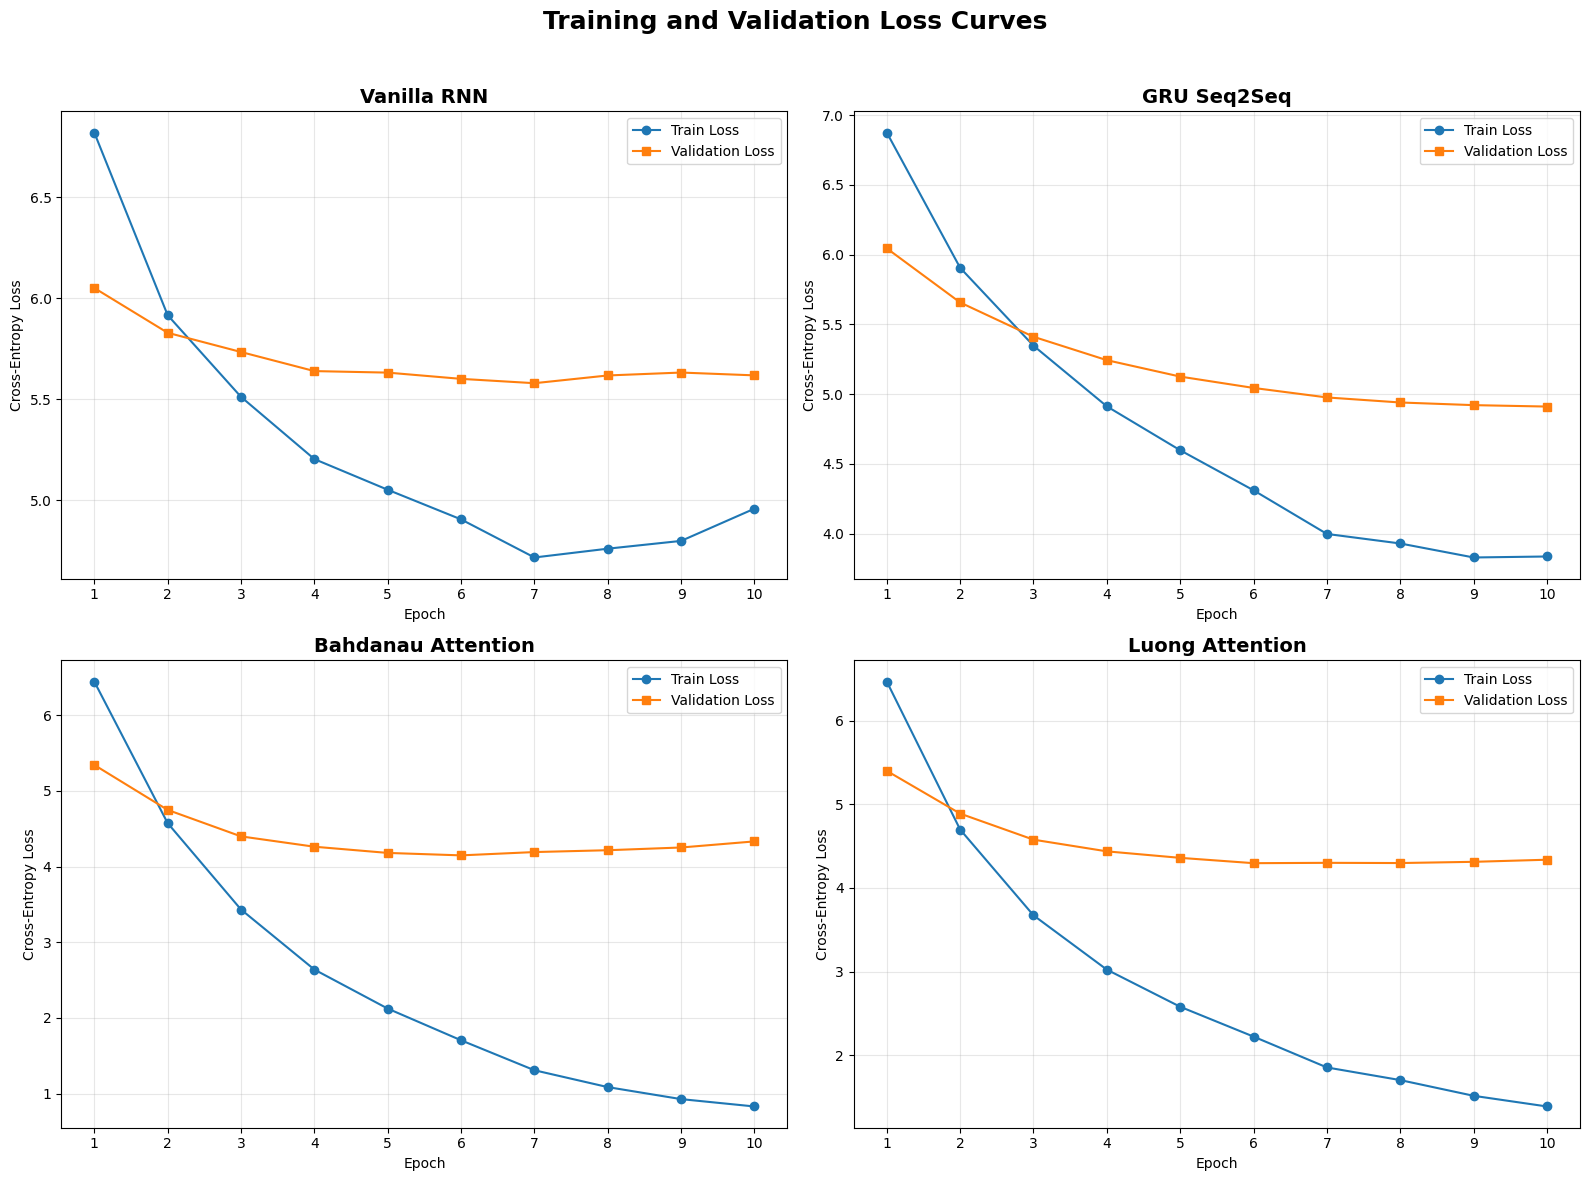

In [29]:
# RESULTS DATAFRAME

result_rows = []

for model_name in MODEL_NAMES:

    r = results[model_name]

    result_rows.append(
        {
            "Model": model_name,
            "Parameters": r["parameters"],
            "BLEU": r["bleu"],
            "Sentence_BLEU": r["sentence_bleu"],
            "Perplexity": r["perplexity"],
            "Mean_Latency_ms": r[
                "latency_mean_ms"
            ],
            "Median_Latency_ms": r[
                "latency_median_ms"
            ],
            "P95_Latency_ms": r[
                "latency_p95_ms"
            ],
            "Training_Time_min": (
                r["training_time_sec"] / 60
            ),
        }
    )


results_df = pd.DataFrame(
    result_rows
)

results_csv = (
    RESULT_DIR /
    "quantitative_results.csv"
)

results_df.to_csv(
    results_csv,
    index=False
)

print("\nQuantitative results:")
print(
    results_df.to_string(
        index=False
    )
)


# LOSS CURVES

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

axes = axes.flatten()

for idx, model_name in enumerate(
    MODEL_NAMES
):

    ax = axes[idx]

    history = histories[
        model_name
    ]

    epochs = np.arange(
        1,
        len(history["train_loss"]) + 1
    )

    ax.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss"
    )

    ax.plot(
        epochs,
        history["val_loss"],
        marker="s",
        label="Validation Loss"
    )

    ax.set_title(
        model_name,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Cross-Entropy Loss"
    )

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    ax.set_xticks(
        epochs
    )

fig.suptitle(
    "Training and Validation Loss Curves",
    fontsize=18,
    fontweight="bold"
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

loss_plot_path = (
    PLOT_DIR /
    "loss_curves_all_models.png"
)

fig.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

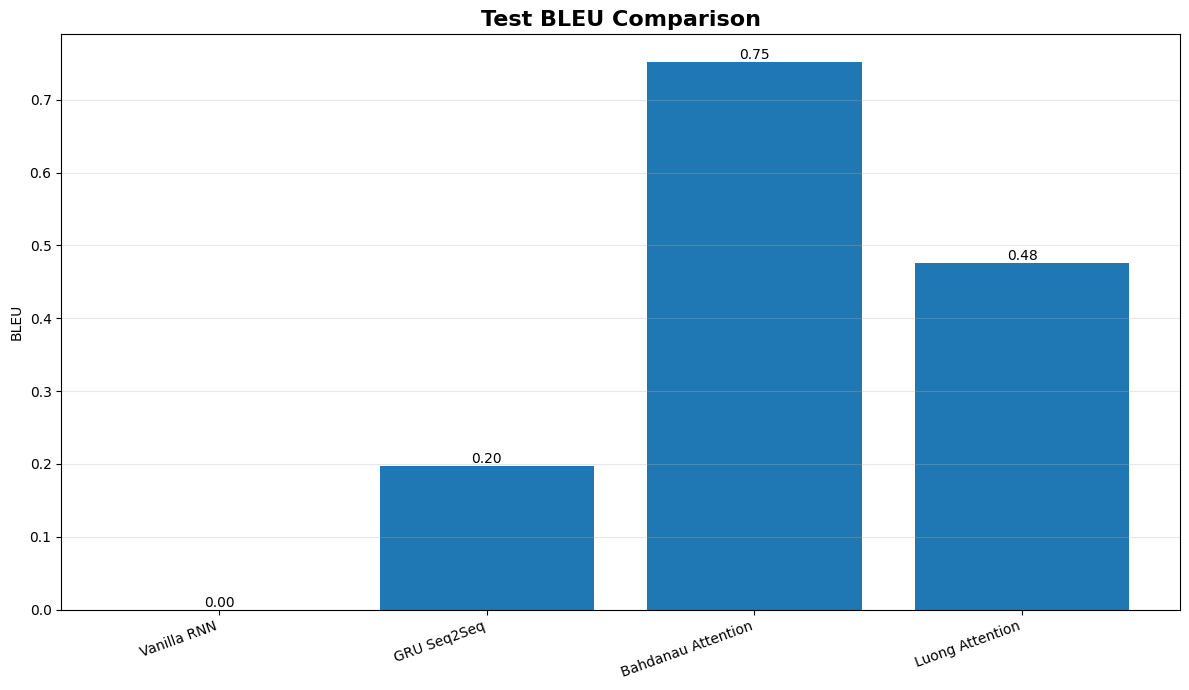

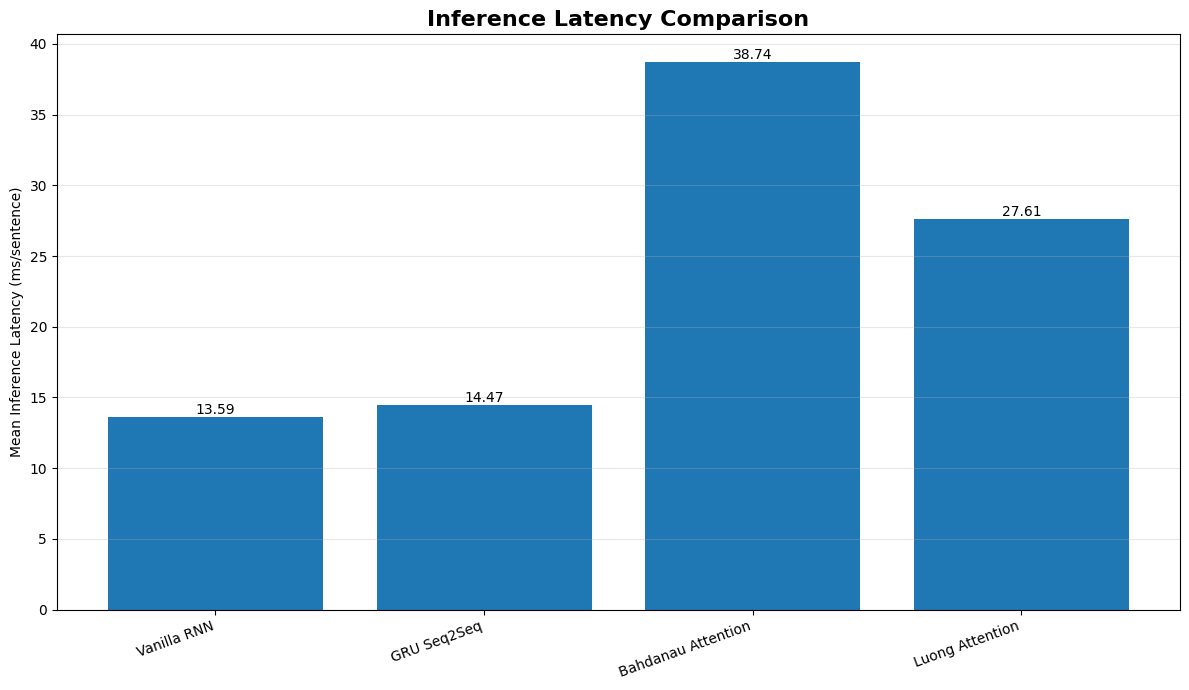

In [33]:
# BLEU COMPARISON

fig, ax = plt.subplots(
    figsize=(12, 7)
)

x = np.arange(
    len(results_df)
)

bars = ax.bar(
    x,
    results_df["BLEU"]
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    results_df["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "BLEU"
)

ax.set_title(
    "Test BLEU Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    results_df["BLEU"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

bleu_plot_path = (
    PLOT_DIR /
    "test_bleu_comparison.png"
)

fig.savefig(
    bleu_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# LATENCY COMPARISON

fig, ax = plt.subplots(
    figsize=(12, 7)
)

bars = ax.bar(
    x,
    results_df["Mean_Latency_ms"]
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    results_df["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel(
    "Mean Inference Latency (ms/sentence)"
)

ax.set_title(
    "Inference Latency Comparison",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    results_df["Mean_Latency_ms"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

latency_plot_path = (
    PLOT_DIR /
    "inference_latency_comparison.png"
)

fig.savefig(
    latency_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

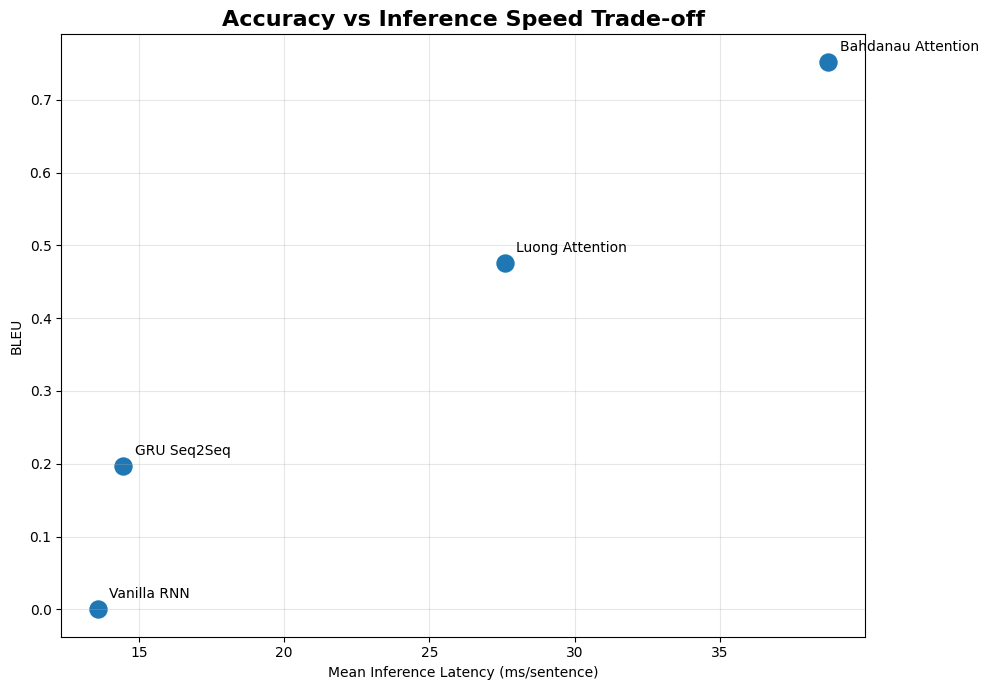

In [34]:
# BLEU VS LATENCY TRADE-OFF
fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.scatter(
    results_df["Mean_Latency_ms"],
    results_df["BLEU"],
    s=150
)

for _, row in results_df.iterrows():

    ax.annotate(
        row["Model"],
        (
            row["Mean_Latency_ms"],
            row["BLEU"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

ax.set_xlabel(
    "Mean Inference Latency (ms/sentence)"
)

ax.set_ylabel(
    "BLEU"
)

ax.set_title(
    "Accuracy vs Inference Speed Trade-off",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.3
)

fig.tight_layout()

tradeoff_plot_path = (
    PLOT_DIR /
    "bleu_vs_latency_tradeoff.png"
)

fig.savefig(
    tradeoff_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [35]:
# QUALITATIVE TRANSLATION EXAMPLES

def classify_sentence_complexity(
    sentence
):

    token_count = len(
        tokenize(sentence)
    )

    if token_count <= 5:
        return "Simple"

    elif token_count <= 12:
        return "Complex"

    return "Long"


# Select examples from test data.
# We deliberately select examples from different lengths.

sorted_test_pairs = sorted(
    test_pairs,
    key=lambda x: len(
        tokenize(x[0])
    )
)

simple_candidates = [
    pair
    for pair in sorted_test_pairs
    if len(tokenize(pair[0])) <= 5
]

complex_candidates = [
    pair
    for pair in sorted_test_pairs
    if 6 <= len(tokenize(pair[0])) <= 12
]

long_candidates = [
    pair
    for pair in sorted_test_pairs
    if len(tokenize(pair[0])) > 12
]


def choose_representative(
    candidates,
    fallback_pairs
):

    if not candidates:
        return fallback_pairs[
            len(fallback_pairs) // 2
        ]

    # Deterministically select middle-ish example.
    return candidates[
        len(candidates) // 2
    ]


qualitative_pairs = [
    (
        "Simple",
        choose_representative(
            simple_candidates,
            test_pairs
        )
    ),
    (
        "Complex",
        choose_representative(
            complex_candidates,
            test_pairs
        )
    ),
    (
        "Long",
        choose_representative(
            long_candidates,
            test_pairs
        )
    ),
]


qualitative_results = []

print("\n")
print("=" * 70)
print("QUALITATIVE TRANSLATION EXAMPLES")
print("=" * 70)

for complexity, pair in qualitative_pairs:

    src_text, reference = pair

    print(
        f"\n[{complexity}]"
    )

    print(
        f"English: {src_text}"
    )

    print(
        f"Reference: {reference}"
    )

    for model_name in MODEL_NAMES:

        prediction, _ = translate_sentence(
            models[model_name],
            src_text
        )

        prediction_text = (
            " ".join(prediction)
        )

        print(
            f"{model_name}: "
            f"{prediction_text}"
        )

        qualitative_results.append(
            {
                "Complexity": complexity,
                "Source": src_text,
                "Reference": reference,
                "Model": model_name,
                "Prediction": prediction_text,
            }
        )


qualitative_df = pd.DataFrame(
    qualitative_results
)

qualitative_csv = (
    RESULT_DIR /
    "qualitative_translations.csv"
)

qualitative_df.to_csv(
    qualitative_csv,
    index=False
)




QUALITATIVE TRANSLATION EXAMPLES

[Simple]
English: my brother is out.
Reference: 형이 나갔다.
Vanilla RNN: 톰은 메리가 그것을 할 것이라는 걸 이미 안다. 있다. 있다. 있다. 있어. 있어. 해. 한다. 수 없다. 있어. 해. 있어. 해. 있어. 해. 있어. 해. 있어. 해. 있어. 해.
GRU Seq2Seq: 내 딸은 교수야. 있다. 있다. 있어. 있다. 있다. 있다. 것이다. 할 수 없었다. 있다. 있다. 수 없었다. 있다. 있다. 수 없었다. 말했다. 말했다. 말했다. 했다. 했다. 적이 없어. 없어.
Bahdanau Attention: 내 딸은 3살일 뿐이야. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다. 있다.
Luong Attention: 내 내 나갔다. 나갔다. 나갔다. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어. 있어.

[Complex]
English: please send it to me by fax.
Reference: 이것을 나에게 팩스로 보내 주세요.
Vanilla RNN: 톰은 메리가 그것을 할 것이라는 걸 이미 안다. 있다. 있다. 있다. 있어. 있어. 해. 한다. 수 없다. 있어. 해. 있어. 해. 있어. 해. 있어. 해. 있어. 해. 있어. 해.
GRU Seq2Seq: 그만 그만 하지 마. 마. 있다. 것이다. 해. 해. 해. 안 된다. 있다. 것이다. 해. 해. 안 된다. 있다. 것이다. 해. 해. 안 된다. 있다. 것이다. 해. 해. 안
Bahdanau Attention: 병원으로 데려다 주세요. 나한테 일곱 시에 수 있을까요? 해줘. 해줘. 나한테 일곱 시에 수 있을까요? 해줘. 나한테 일곱 시에 수 있을